# Data Mining
# Week 11
# Submitter - Himanshu Singh
# Building a CNN Image Classifier

In this exercise, you will build a convolutional neural network (CNN) to classify handwritten digits from the MNIST dataset. The steps to build this CNN classifier with PyTorch are provided in section 22.1 of Machine Learning with Python Cookbook 2nd Edition. The steps to do this with TensorFlow are outlined in section 20.15 of the Machine Learning with Python Cookbook 1st Edition or at various web links, e.g., https://www.kaggle.com/code/amyjang/tensorflow-mnist-cnn-tutorial. Keep in mind that your code may need to be modified depending on your library versions of PyTorch, Keras, and Tensorflow.

Perform the following steps for this exercise.

* Load the MNIST data set.
* Display the first five images in the training data set. Compare these to the first five training labels.
* Build and train a CNN classifier on the MNIST training set.
* Report the test accuracy of your model.
* Display a confusion matrix on the test set classifications.
* Summarize your results.

In [12]:
# Importing necessary libraries

import tensorflow as tf
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import warnings
warnings.filterwarnings('ignore')
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print(tf.__version__)

2.20.0


In [13]:
# Loading the MNIST dataset

# Load data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values to be between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

# Reshape to include channel dimension (28, 28, 1)
x_train = x_train.reshape((-1, 28, 28, 1))
x_test = x_test.reshape((-1, 28, 28, 1))

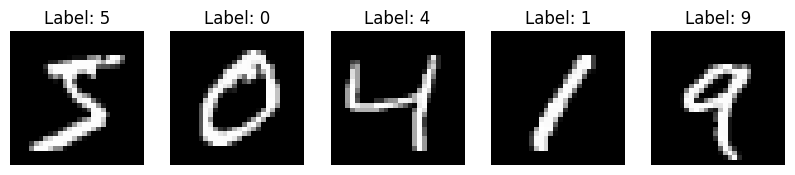

First 5 Training Labels: [5 0 4 1 9]


In [14]:
# Visualize the first 5 training images and their labels

plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

print(f"First 5 Training Labels: {y_train[:5]}")

In [15]:
# Build  and Train a simple CNN model

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train for 5 epochs
model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.1)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8724 - loss: 0.4143 - val_accuracy: 0.9802 - val_loss: 0.0647
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9814 - loss: 0.0602 - val_accuracy: 0.9868 - val_loss: 0.0464
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9875 - loss: 0.0402 - val_accuracy: 0.9890 - val_loss: 0.0390
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9905 - loss: 0.0296 - val_accuracy: 0.9875 - val_loss: 0.0413
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9927 - loss: 0.0224 - val_accuracy: 0.9913 - val_loss: 0.0333



Test Accuracy: 0.9897
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


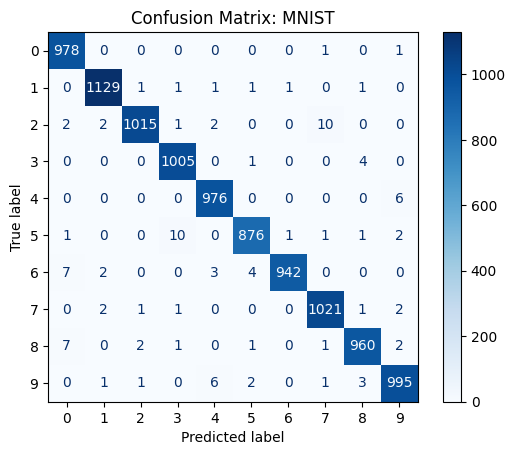

In [16]:
# Evaluate the model on test data and generate confusion matrix

# Report Accuracy
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")

# Generate Confusion Matrix
y_pred = np.argmax(model.predict(x_test), axis=1)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix: MNIST")
plt.show()

# Summary of Results


## Performance: CNNs achieves >98% accuracy on MNIST within just a few epochs.

## Insights: The confusion matrix shows minor errors between visually similar digits. 

### Most Accurate: Digit 1 had the highest number of correct classifications (1129).
### Most Difficult: Digit 5 appears to have the lowest correct count (876) relative to the others, though it is still highly accurate.

## Key "Confusions" (Errors)
### By looking at the light blue squares outside the diagonal, we can see exactly where the model tripped up. The most significant errors are:

#### 5 vs. 3: The model misclassified a "5" as a "3" ten times. This is a common error because the bottom curves of 3s and 5s are nearly identical in many handwriting styles.

#### 2 vs. 7: The model misclassified a "2" as a "7" ten times. If the base of a "2" is written very flat or the top is sharp, it can easily resemble a "7."

#### 4 vs. 9: There were 6 instances where a "4" was predicted as a "9," and 6 instances where a "9" was predicted as a "4." Their vertical stalks and closed/semi-closed loops make them visually similar.

## Architecture: The convolutional layers effectively extract spatial features (edges and loops), making them far superior to simple flat dense networks for this task.